In [1]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "djuarez7-KSU"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Factorial Designs"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/djuarez7-KSU/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/djuarez7-KSU/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Factorial Designs


# Instagram Ad Factorial Design Example
## Dr Austin R Brown
### School of Data Science and Analytics
### Kennesaw State University


## Introduction

You work for a digital marketing agency. This agency wants to determine the effectiveness of two different types of Instagram ads on user engagement. They want to know if the ad format (image or video) and the ad content (funny or promotional) have an impact on the amount of time viewing the ad. To evaluate this, they recruit 100 participants and randomly assign them to one of the four conditions: image-funny, image-promotional, video-funny, or video-promotional. The participants are then asked to view the ad and the time they spend viewing the ad (in seconds) is recorded. The data are contained in the `Instagram Data.xlsx` file. With these data, I want you to:

## Question 1: Briefly define the objective of this experiment

the objective is to determine which combination of factors yield the greatest mean watch time of an Instagram ad.

## Question 2: Specify the outcome variable

Time spend viewing the ad (continuous, quantitative variable)

## Question 3: Specify the independent variables. What are some other possible lurking variables?

First IV: Ad Format (Imagen or Video) (nominal, categorica variable)
Second IV: Ad Content (Funny or Promotional) (nominal, categorical variables)
Possible Lurking variables: (1) Humor type, (2) Audio quality, (3) color scheme, (4) other demographic variables

## Question 4: State all of the pairs of null and alternative hypotheses for this experiment.

the model we're fitting is:

$$ \text{Time}_{ijk} = \mu + \alpha_i + \beta_j + (\alpha\beta_{ij} + \varepsilon_{ijk} $$

$$ H_{01}: \alpha_{\text{image}} =  \alpha_{\text{video}} = 0 $$
$$ H_{11}: \text{Either } \alpha_{\text{image}} \neq 0 \space \space \space \text{or} \alpha_{\text{video}} \neq 0 $$

$$ H_{02}: \beta_{\text{funny}} =  \beta_{\text{promo}} = 0 $$
$$ H_{12}: \text{Either } \beta_{\text{funny}} \neq 0 \space \space \space \text{or} \beta_{\text{promo}} \neq 0 $$

$$ H_{03}: (\alpha\beta)_{if} = (\alpha\beta)_{ip} = (\alpha\beta)_{vf} = (\alpha\beta)_{ip} = 0$$
$$ H_{13}: \text{At least one combination of } (\alpha\beta)_{ij} \neq 0 $$

## Question 5: Perform appropriate exploratory analysis, including data visualizations and summary statistics. Do the results of these analyses support the null or alternative hypotheses more strongly?



In [10]:
#Import pandas library
import pandas as pd

#Import the dataset for the example
insta = pd.read_excel("Instagram Data.xlsx")

#Data check
print(insta.info())

#calculate means and SD of the first treatment variable
format_stats = insta.groupby("Format")['Time'].agg(['mean', 'std'])
print(format_stats)

content_stats = insta.groupby('Content')["Time"].agg(['mean', 'std'])
print(content_stats)

#check mean and std of the interactions format * content
interaction_stats = insta.groupby(["Format", "Content"])["Time"].agg(['mean', 'std'])
print(interaction_stats)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Format   100 non-null    object 
 1   Content  100 non-null    object 
 2   Time     100 non-null    float64
dtypes: float64(1), object(2)
memory usage: 2.5+ KB
None
           mean        std
Format                    
Image    7.9562   5.511322
Video   26.9986  11.075941
                  mean        std
Content                          
Funny          24.0064  14.060813
Informational  10.9484   7.304500
                         mean       std
Format Content                         
Image  Funny          11.1960  5.509555
       Informational   4.7164  3.129290
Video  Funny          36.8168  5.604221
       Informational  17.1804  4.269660


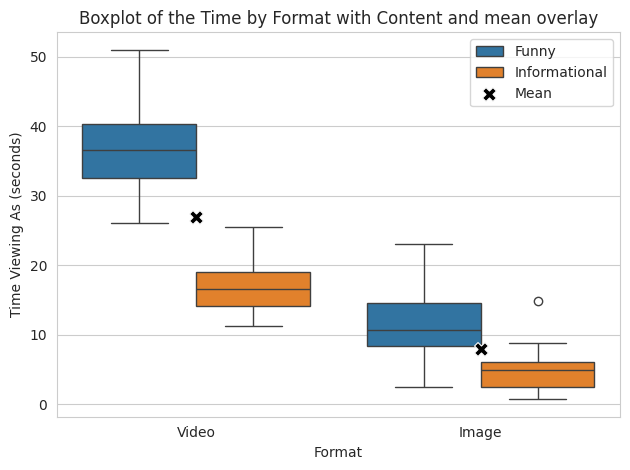

In [15]:
#import seaborn and matplot library
import seaborn as sns
import matplotlib.pyplot as plt

#create boxplot using seaborn
sns.set_style("whitegrid")

sns.boxplot(
    data = insta,
    x = 'Format',
    y = 'Time',
    hue = 'Content'
)

#calculate means per format

mean_points = insta.groupby('Format')['Time'].mean().reset_index()

#overlay mean points
sns.scatterplot(
    data = mean_points,
    x = 'Format',
    y = 'Time',
    color = 'black',
    marker = 'X',
    s = 100,
    label = "Mean",
    zorder = 3
)

#add labels to the plot
plt.title('Boxplot of the Time by Format with Content and mean overlay')
plt.ylabel("Time Viewing As (seconds)")
plt.xlabel("Format")
plt.legend()
plt.tight_layout()
plt.show()


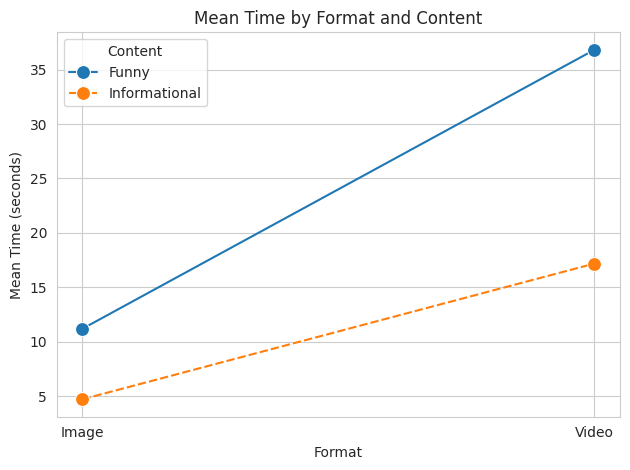

In [18]:
#other option
int_means = insta.groupby(['Format', 'Content'])['Time'].mean().reset_index()

#create the plot
sns.set_style('whitegrid')
sns.lineplot(
    data = int_means,
    x = 'Format',
    y = 'Time',
    hue = 'Content',
    marker = 'o',
    markersize = 10,
    style = "Content"
)

#add titles and labs
plt.title("Mean Time by Format and Content")
plt.xlabel('Format')
plt.ylabel('Mean Time (seconds)')
plt.legend(title = 'Content')
plt.tight_layout()
plt.show()

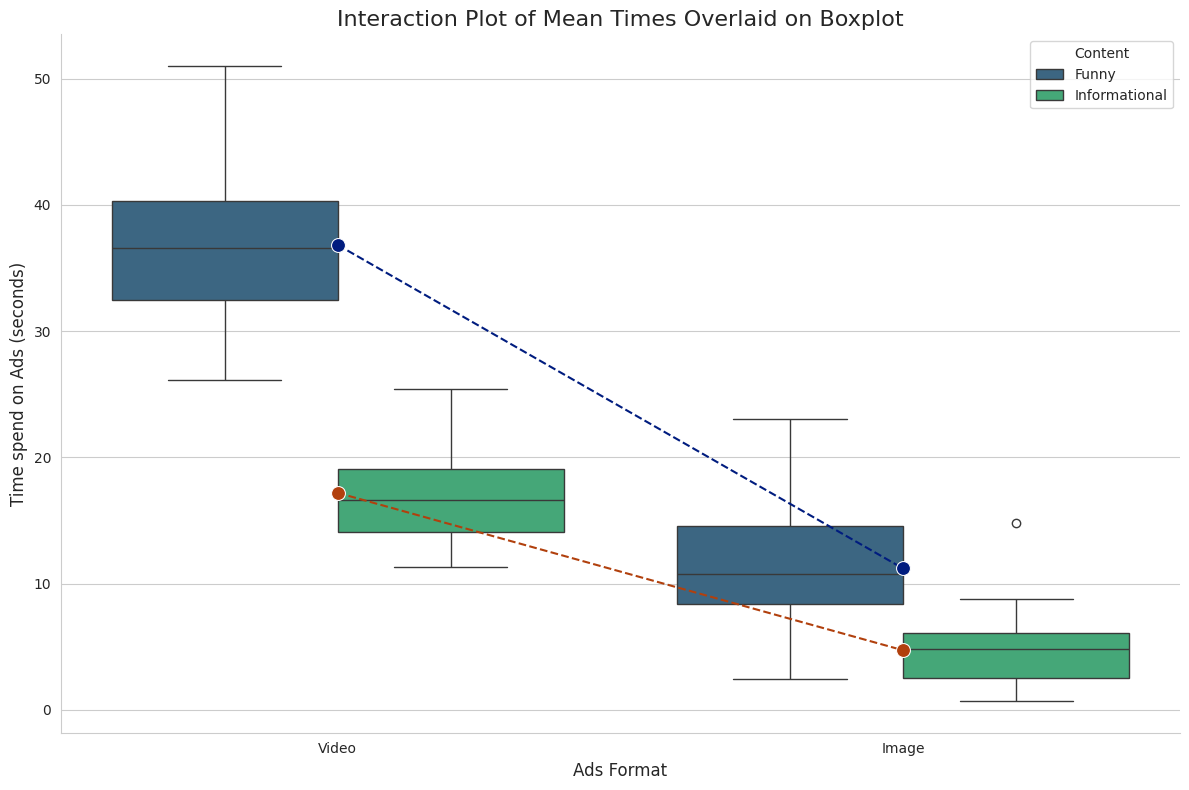

In [19]:
#another and better option
## Step 1: Create a figure and a single axes object to plot on. ##

fig, ax = plt.subplots(figsize=(12, 8))

## Step 2: Plot the boxplot first, on the raw data.
## We set 'ax=ax' to ensure it's drawn on our specified axes.
## 'dodge=True' separates the boxes for different padding types.
## 'zorder=2' places it below the line plot. ##

sns.boxplot(data=insta, x='Format', y='Time', hue='Content',
            palette='viridis', dodge=True, ax=ax, zorder=2)

## Step 3: Overlay the interaction plot (line plot of the means).
## Seaborn's lineplot() can automatically calculate the mean for each group.
## We use the same 'x', 'y', and 'hue' to ensure alignment.
## We specify 'marker' to show the points at the means.
## 'zorder=3' places it on top of the boxplot for better visibility.

sns.lineplot(data=insta, x='Format', y='Time', hue='Content',
             marker='o', markersize=10, ax=ax, zorder=3,
             estimator='mean', err_style=None, linestyle='--',
             palette='dark')

## Note: The `err_style=None` and `estimator='mean'` parameters in lineplot()
## ensure that it plots just the mean line without confidence intervals. ##

## Step 4: Clean up the plot: set titles, labels, and theme. ##

ax.set_title('Interaction Plot of Mean Times Overlaid on Boxplot', fontsize=16)
ax.set_xlabel('Ads Format', fontsize=12)
ax.set_ylabel('Time spend on Ads (seconds)', fontsize=12)

## Adjust legend to avoid duplicate labels ##
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Content')

## Apply a classic theme by removing the top and right spines. ##

sns.despine()
plt.tight_layout()

## Show Plot ##

plt.show()

## Question 6: Build a two-way ANOVA model including the two-way interaction. Test the assumption of normality using both a visual method and an inferential method. Do the results of the normality test(s) support the assumption of normality?



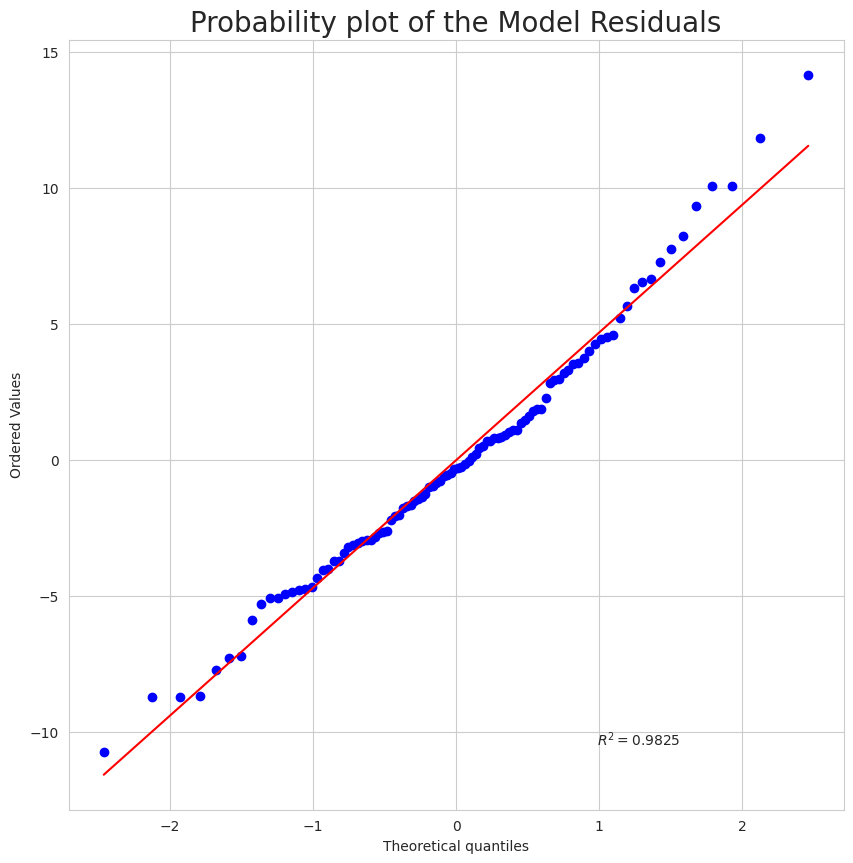

ShapiroResult(statistic=np.float64(0.9835741686203486), pvalue=np.float64(0.24955808378856326))


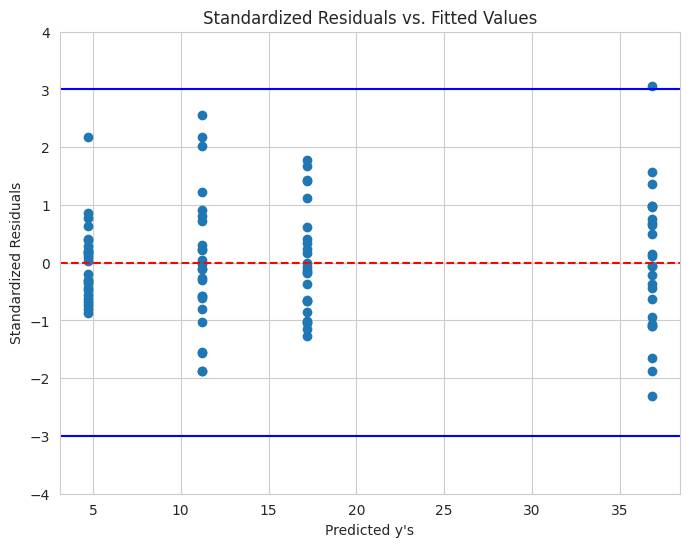

F-statistic: 2.289239902191066
F p-value: 0.08328985225365272


In [23]:
#import libraries for run the ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

#Fit the ANOVA model
mod = ols('Time~Format*Content', data = insta).fit()

#test Normality
#QQ-Plot
#extract model residuals
residuals = mod.resid

#generate QQ plot

fig = plt.figure(figsize = (10,10))
ax =fig.add_subplot(111)


normality_plot, stat = stats.probplot(residuals, plot = plt, rvalue = True)
ax.set_title("Probability plot of the Model Residuals", fontsize = 20)
ax.set

plt.show()

#S-W test
print(stats.shapiro(residuals))



## Question 7: Test the assumption of homogeneity of variance using both a visual method and an inferential method. Do the results of the test(s) support the assumption of homogeneity of variance?

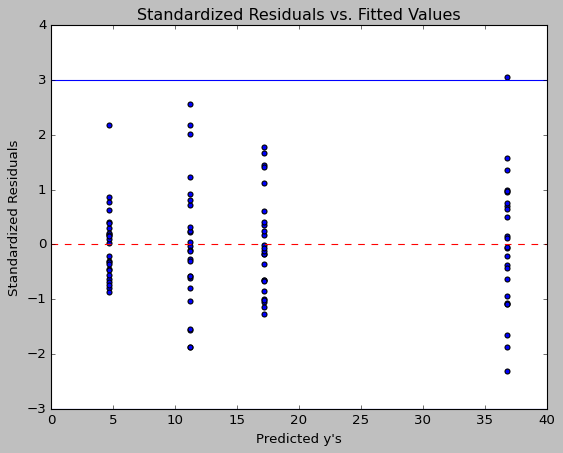

F-statistic: 2.289239902191066
F p-value: 0.08328985225365272


In [25]:
## Constant Variance ##

## Scatterplot of Standardized Residuals to Fitted Values ##

## Obtain Standardized Residuals ##

standardized_residuals = mod.get_influence().resid_studentized_internal

## Get the fitted values ##

fitted_values = mod.fittedvalues

## Create the plot ##

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()

## B-P Test ##

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(mod.resid,mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")



## Question 8: Report the F-statistic for the interaction effect and its associated p-value from the twoway ANOVA model. Which of our two hypotheses is more strongly supported? Why?

## Question 9: Report the F-statistics for the main effects and their associated p-values from the twoway ANOVA model. Which of our two hypotheses is more strongly supported? Why?



In [24]:
#print ANOVA table
print(sm.stats.anova_lm(mod, typ = 3))

                     sum_sq    df           F        PR(>F)
Intercept       3133.760400   1.0  139.611847  2.013128e-20
Format          8205.317408   1.0  365.554276  1.680655e-34
Content          524.815202   1.0   23.380990  5.049105e-06
Format:Content  1081.883664   1.0   48.198891  4.550478e-10
Residual        2154.838616  96.0         NaN           NaN


## Question 10: If the data more strongly support the alternative hypothesis in any of the above F-tests, perform Tukey’s HSD post-hoc test to determine which groups significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

## Question 11: Write a brief conclusion summarizing the results of your analyses and include at least one potential limitation of the study.